## Access Vessel Bio Optical Absorption Delayed QC data (Parquet)

This notebook accesses **in-situ spectral absorption coefficients** from the
[IMOS Bio-Optical Database of Australian Waters (BODBAW)](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/97b9fe73-ee44-437f-b2ae-5b8613f81042)
and produces the visualisations most commonly used in the ocean-colour literature.

### About the dataset
The dataset contains four optically distinct absorption components measured at discrete depth profiles
across Australian coastal and open-ocean field campaigns:

| Column | Component | Oceanographic meaning |
|---|---|---|
| `ag` | CDOM (Gelbstoff) | Coloured Dissolved Organic Matter — exponential decay toward blue, key driver of satellite water-colour algorithms |
| `ad` | Non-Algal Detritus (NAD) | Particles other than phytoplankton — sediment, dead organic matter |
| `aph` | Phytoplankton | Chlorophyll and accessory pigments — two peaks at ~440 nm and ~675 nm |
| `ac9_a_corr` | Total in-situ (AC-9) | All non-water absorption from an in-situ flow-through AC-9 sensor |
| `ac9_c_corr` | Total attenuation (AC-9) | Absorption + scattering from AC-9 sensor |

The data are stored in **long format**: one row per `(profile observation × wavelength)`.
Wavelengths span **350–800 nm** at ~1.33 nm resolution (338 bands).

📌 Source maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/blob/main/notebooks/vessel_bio_optical_absorption_delayed_qc.ipynb)


In [1]:
dataset_name = "vessel_bio_optical_absorption_delayed_qc"

## Install/Update packages and Load common functions

In [2]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

Using Python 3.12.6 environment at: /home/lbesnard/github_repo/aodn_cloud_optimised/.venv
Resolved 155 packages in 49ms
Checked 155 packages in 0.99ms


✅ Virtual environment already exists, skipping creation.
✅ Local version 0.3.13 is up to date (remote: 0.3.13)


In [3]:
from DataQuery import GetAodn

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:4063: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


# Understanding the Dataset

## Understanding Parquet Partitioning

Parquet files can be **partitioned** by one or more columns, which means the data is physically organised into folders based on the values in those columns. This is similar to how databases use indexes to optimise query performance.

Partitioning enables **faster filtering**: when you query data using a partitioned column, only the relevant subset of files needs to be read—improving performance significantly.

For example, if a dataset is partitioned by `"site_code"`, `"timestamp"`, and `"polygon"`, filtering on `"site_code"` allows the system to skip unrelated files entirely.

In this notebook, the `GetAodn` class includes built-in methods to efficiently filter data by **time** and **latitude/longitude** using the **timestamp** and **polygon** partitions. Other partitions can be used for filtering via the `scalar_filter`.

Any filtering on columns that are **not** partitioned can be significantly slower, as all files may need to be scanned. However, the `GetAodn` class provides a `scalar_filter` method that lets you apply these filters at load time—before the data is fully read—helping reduce the size of the resulting DataFrame.

Once the dataset is loaded, further filtering using Pandas is efficient and flexible.

See further below in the notebook for examples of how to filter the data effectively.

To view the actual partition columns for this dataset, run:


In [4]:
aodn = GetAodn()
dname = f'{dataset_name}.parquet'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 8.95 ms, sys: 3.98 ms, total: 12.9 ms
Wall time: 13 ms


In [5]:
aodn_dataset.dataset.partitioning.schema

timestamp: int32
polygon: string

## List unique partition values

In [6]:
%%time
unique_partition_value = aodn_dataset.get_unique_partition_values('YOUR_PARTITION_KEY')
print(list(unique_partition_value)[0:2])  # showing a subset only

[]
CPU times: user 3.34 ms, sys: 728 µs, total: 4.06 ms
Wall time: 2.63 ms


## Visualise Spatial Extent of the dataset
This section plots the polygons representing the areas where data is available. It helps to identify and create a bounding box around the regions containing data.

/home/lbesnard/github_repo/aodn_cloud_optimised/.venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


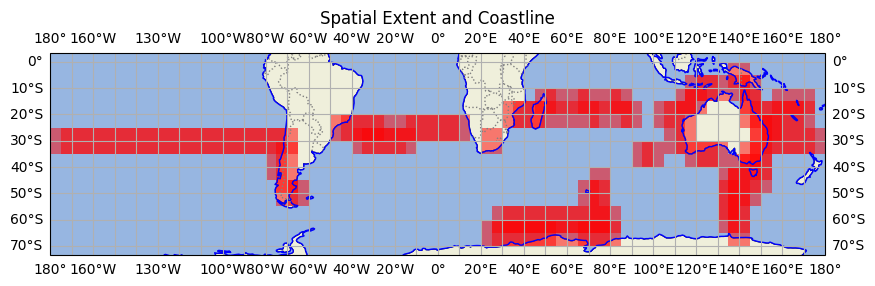

In [7]:
aodn_dataset.plot_spatial_extent()

## Get Temporal Extent of the dataset

Similary to the spatial extent, we're retrieving the minimum and maximum timestamp partition values of the dataset. This is not necessarely accurately representative of the TIME values, as the timestamp partition can be yearly/monthly... but is here to give an idea

In [8]:
%%time
aodn_dataset.get_temporal_extent()

CPU times: user 81.7 ms, sys: 66.2 ms, total: 148 ms
Wall time: 312 ms


(Timestamp('1996-07-01 23:48:00'), Timestamp('2024-07-31 00:12:00.000000256'))

## Read Metadata

For all Parquet datasets, we create a sidecar file named **_common_metadata** in the root of the dataset. This file contains both the dataset-level and variable-level attributes.  
The metadata can be retrieved below as a dictionary, and it will also be included in the pandas DataFrame when using the `get_data` method from the `GetAodn` class.

In [9]:
metadata = aodn_dataset.get_metadata()
metadata

2026-04-29 10:32:44,138 - aodn.GetAodn - INFO - Retrieving metadata for aodn-cloud-optimised/vessel_bio_optical_absorption_delayed_qc.parquet


{'timestamp': {'type': 'int64',
  'units': '1',
  'long_name': 'Partition timestamp'},
 'polygon': {'type': 'string',
  'units': '1',
  'long_name': 'Spatial partition polygon'},
 'filename': {'type': 'string',
  'units': '1',
  'long_name': 'Filename of the source file'},
 'TIME': {'type': 'timestamp[ns]',
  'axis': 'T',
  'long_name': 'time',
  'standard_name': 'time'},
 'LATITUDE': {'type': 'float',
  'axis': 'Y',
  'long_name': 'latitude',
  'reference_datum': 'geographical coordinates, WGS84 projection',
  'standard_name': 'latitude',
  'units': 'degrees_north',
  'valid_max': 90.0,
  'valid_min': -90.0},
 'LONGITUDE': {'type': 'float',
  'axis': 'X',
  'long_name': 'longitude',
  'reference_datum': 'geographical coordinates, WGS84 projection',
  'standard_name': 'longitude',
  'units': 'degrees_east',
  'valid_max': 180.0,
  'valid_min': -180.0},
 'DEPTH': {'type': 'float',
  'axis': 'Z',
  'long_name': 'depth',
  'positive': 'down',
  'reference_datum': 'sea surface',
  'standar

# Data Query and Plot

## Create a TIME and BoundingBox filter

This cell loads a subset of the dataset based on a time range and a spatial bounding box. The result is returned as a pandas DataFrame, and basic information about its structure is displayed.

In [10]:
%%time
df = aodn_dataset.get_data(#date_start='1994-01-01',
                           #date_end='2023-12-31',
                           lat_min=-45,
                           lat_max=-20,
                           lon_min=110,
                           lon_max=130,
                           )

print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")
print(f"Unique wavelengths: {df['wavelength'].nunique()}")
print(f"Unique profiles (TIME × station_name): {df.groupby(['TIME','station_name']).ngroups}")
df.head(3)


2026-04-29 10:32:46,617 - aodn.GetAodn - INFO - Retrieving metadata for aodn-cloud-optimised/vessel_bio_optical_absorption_delayed_qc.parquet


Rows: 261,001  |  Columns: 14
Unique wavelengths: 750
Unique profiles (TIME × station_name): 137
CPU times: user 367 ms, sys: 135 ms, total: 502 ms
Wall time: 2.4 s


,filename,TIME,LATITUDE,LONGITUDE,DEPTH,station_name,wavelength,ag,ad,aph,ac9_a_corr,ac9_c_corr,timestamp,polygon
0,IMOS_SRS-OC-BODBAW_X_20030527T015700Z_JurienBa...,2003-05-28 04:15:59.999999872,-30.243349,114.96405,0.0,J3,800.000000,0.008573,NaN,NaN,NaN,NaN,1041379200,010300000001000000050000000000000000405A400000...
1,IMOS_SRS-OC-BODBAW_X_20030527T015700Z_JurienBa...,2003-05-28 04:15:59.999999872,-30.243349,114.96405,0.0,J3,798.666687,0.008661,NaN,NaN,NaN,NaN,1041379200,010300000001000000050000000000000000405A400000...
2,IMOS_SRS-OC-BODBAW_X_20030527T015700Z_JurienBa...,2003-05-28 04:15:59.999999872,-30.243349,114.96405,0.0,J3,797.333374,0.008749,NaN,NaN,NaN,NaN,1041379200,010300000001000000050000000000000000405A400000...


In [11]:
## Download Subsetted Data as CSV

# This cell downloads the filtered dataset as a ZIP-compressed CSV file.  
# The CSV includes metadata at the top as commented lines, and a `FileLink` object is returned to allow downloading directly from the notebook.


#df.aodn.download_as_csv()

## Create a TIME and scalar/number filter

This cell filters the dataset by time range and a scalar value (from a Parquet partition) using the `scalar_filter` argument.  
This leverages Parquet partitioning to apply efficient, server-side filtering, which significantly speeds up data loading.

## Surface Absorption Spectra

The most fundamental ocean-colour plot: absorption coefficient **a(λ)** vs wavelength at the
sea surface (depth ≤ 2 m), plotted separately for ag, ad, and aph.

Characteristic spectral shapes:
- **ag** — monotonically decreasing from UV to NIR, well described by an exponential `ag(λ) = ag(λ₀) exp(-Sg(λ−λ₀))`.
  Strong CDOM means high ag in the blue, making the water appear yellow-brown.
- **ad** — also exponential but flatter than ag; dominates in turbid/coastal waters.
- **aph** — two absorption peaks: the **Soret band** near **440 nm** (mainly Chl-a) and the
  **red band** near **675 nm** (Chl-a red peak). The blue/red ratio depends on pigment packaging.

Individual profiles are shown as thin translucent lines; the **median spectrum** is the thick coloured line.


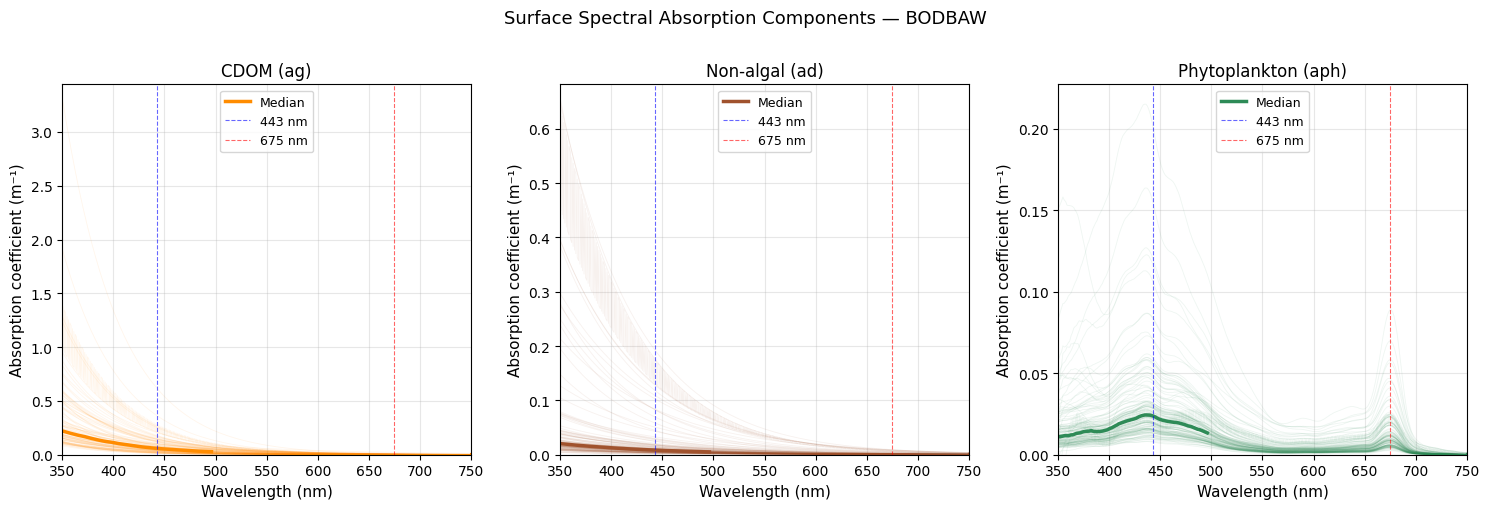

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Surface only; sort wavelengths ascending for conventional spectral x-axis
df_surf = df[df['DEPTH'] <= 2].copy()
df_surf = df_surf.sort_values('wavelength')

components = {
    'ag':  ('CDOM (ag)',      'darkorange'),
    'ad':  ('Non-algal (ad)', 'sienna'),
    'aph': ('Phytoplankton (aph)', 'seagreen'),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, (var, (label, color)) in zip(axes, components.items()):
    if var not in df_surf.columns:
        ax.set_visible(False)
        continue

    # One spectrum per (TIME, station_name) pair
    for _, grp in df_surf.groupby(['TIME', 'station_name']):
        g = grp.dropna(subset=[var]).sort_values('wavelength')
        if len(g) < 10:
            continue
        ax.plot(g['wavelength'], g[var], color=color, alpha=0.08, linewidth=0.6)

    # Median spectrum across all profiles at each wavelength
    med = df_surf.groupby('wavelength')[var].median()
    ax.plot(med.index, med.values, color=color, linewidth=2.5, label='Median')

    ax.set_xlabel('Wavelength (nm)', fontsize=11)
    ax.set_ylabel('Absorption coefficient (m⁻¹)', fontsize=11)
    ax.set_title(label, fontsize=12)
    ax.set_xlim(350, 750)
    ax.set_ylim(bottom=0)
    ax.axvline(443, color='blue',  linestyle='--', linewidth=0.8, alpha=0.6, label='443 nm')
    ax.axvline(675, color='red',   linestyle='--', linewidth=0.8, alpha=0.6, label='675 nm')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Surface Spectral Absorption Components — BODBAW', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## Spectral Decomposition at Surface

Showing the **relative contribution** of each component to total non-water absorption at the surface.
The median spectra of ag, ad, and aph are stacked so that total height = ag + ad + aph at each wavelength.

This is the standard way to assess whether a water body is *phytoplankton-dominated* (blue, especially
in the red peak at 675 nm) or *CDOM/detritus-dominated* (orange/brown, especially in the blue).


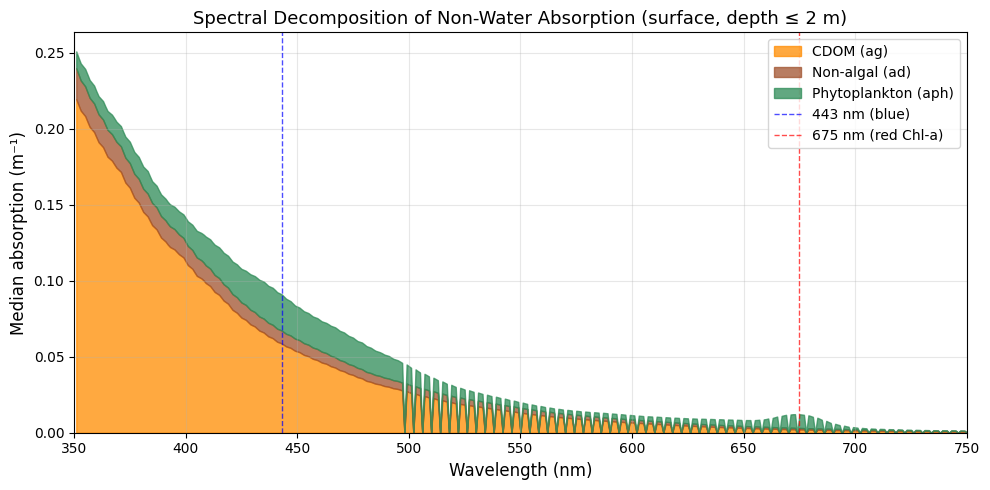

In [13]:
import matplotlib.pyplot as plt
import numpy as np

df_surf = df[df['DEPTH'] <= 2].sort_values('wavelength')
wl_bins = np.arange(350, 751, 5)  # 5-nm bins for clarity
df_surf['wl_bin'] = np.interp(df_surf['wavelength'], wl_bins, wl_bins,
                               left=np.nan, right=np.nan).round()

avail = [v for v in ('ag', 'ad', 'aph') if v in df_surf.columns]
if not avail:
    print("No absorption components found in filtered data.")
else:
    medians = {}
    for var in avail:
        medians[var] = df_surf.groupby('wl_bin')[var].median()

    # Align on common wavelength bins
    common_wl = sorted(set.intersection(*[set(m.index) for m in medians.values()]))
    values = {v: medians[v].reindex(common_wl).fillna(0).clip(lower=0) for v in avail}

    fig, ax = plt.subplots(figsize=(10, 5))
    bottom = np.zeros(len(common_wl))
    colors_map = {'ag': 'darkorange', 'ad': 'sienna', 'aph': 'seagreen'}
    labels_map = {'ag': 'CDOM (ag)', 'ad': 'Non-algal (ad)', 'aph': 'Phytoplankton (aph)'}

    for var in avail:
        ax.fill_between(common_wl, bottom, bottom + values[var].values,
                        alpha=0.75, color=colors_map[var], label=labels_map[var])
        bottom += values[var].values

    ax.set_xlabel('Wavelength (nm)', fontsize=12)
    ax.set_ylabel('Median absorption (m⁻¹)', fontsize=12)
    ax.set_title('Spectral Decomposition of Non-Water Absorption (surface, depth ≤ 2 m)', fontsize=13)
    ax.set_xlim(350, 750)
    ax.set_ylim(bottom=0)
    ax.axvline(443, color='blue', linestyle='--', linewidth=1, alpha=0.7, label='443 nm (blue)')
    ax.axvline(675, color='red',  linestyle='--', linewidth=1, alpha=0.7, label='675 nm (red Chl-a)')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Spatial Distribution at 443 nm

**443 nm** is the most important wavelength for satellite ocean-colour: it is the standard
reference for CDOM and phytoplankton retrievals (SeaWiFS, MODIS, OLCI all carry a 443 nm band).

The map shows `ag(443)` — higher values (warmer colours) indicate stronger CDOM absorption
and typically correspond to coastal, river-influenced, or shallow waters.


Using wavelength: 442.70 nm (closest to 443 nm)


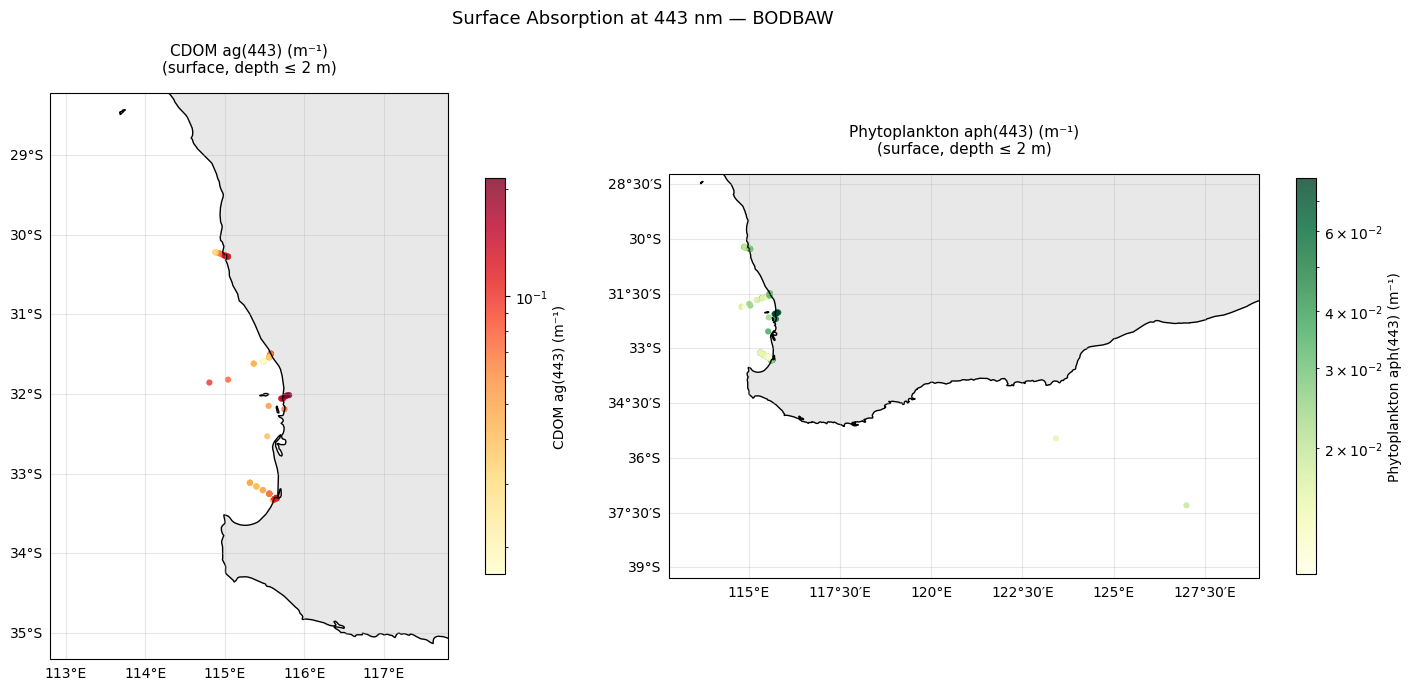

In [14]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Find wavelength closest to 443 nm
target_wl = 443
all_wl = df['wavelength'].dropna().unique()
nearest_wl = all_wl[np.argmin(np.abs(all_wl - target_wl))]
print(f"Using wavelength: {nearest_wl:.2f} nm (closest to {target_wl} nm)")

# Keep all absorption types — do NOT pre-filter on a single variable
# (ag, ad, aph are sparse: each row only has one non-null absorption column)
df_443 = df[(df['wavelength'].round(1) == round(nearest_wl, 1)) & (df['DEPTH'] <= 2)].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                         subplot_kw={'projection': ccrs.PlateCarree()})

for ax, (var, label, cmap) in zip(axes, [
        ('ag',  'CDOM ag(443) (m⁻¹)',           'YlOrRd'),
        ('aph', 'Phytoplankton aph(443) (m⁻¹)', 'YlGn'),
    ]):
    sub = df_443.dropna(subset=[var, 'LATITUDE', 'LONGITUDE'])

    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle=':')

    if sub.empty:
        ax.set_title(f'{label}\n(no data)', fontsize=11)
        continue

    sc = ax.scatter(sub['LONGITUDE'], sub['LATITUDE'],
                    c=sub[var],
                    norm=mcolors.LogNorm(vmin=sub[var].quantile(0.05).clip(1e-4),
                                         vmax=sub[var].quantile(0.95)),
                    cmap=cmap, s=20, alpha=0.8, edgecolors='none',
                    transform=ccrs.PlateCarree())

    plt.colorbar(sc, ax=ax, label=label, shrink=0.7, pad=0.05)

    lon_min, lon_max = sub['LONGITUDE'].min(), sub['LONGITUDE'].max()
    lat_min, lat_max = sub['LATITUDE'].min(),  sub['LATITUDE'].max()
    ax.set_extent([lon_min - 2, lon_max + 2, lat_min - 2, lat_max + 2])

    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha=0.3)
    gl.top_labels   = False
    gl.right_labels = False

    ax.set_title(f'{label}\n(surface, depth ≤ 2 m)', fontsize=11, pad=15)

plt.suptitle('Surface Absorption at 443 nm — BODBAW', fontsize=13)
plt.tight_layout()
plt.show()


## CDOM Spectral Slope (S_g)

CDOM absorption follows an **exponential decay**:

$$a_g(\lambda) = a_g(\lambda_0) \cdot \exp\!\left(-S_g \cdot (\lambda - \lambda_0)\right)$$

The spectral slope **S_g** (units: nm⁻¹) is a key parameter used in:
- Satellite remote-sensing algorithms to separate CDOM from phytoplankton
- Estimating the age, source, and photo-degradation state of dissolved organic matter

**Typical values:** S_g ≈ 0.010–0.020 nm⁻¹ (coastal) to ~0.025 nm⁻¹ (open ocean)

We fit S_g in the wavelength range 350–500 nm using a log-linear regression.


Profiles fitted: 100
Sg median: 15.48 × 10⁻³ nm⁻¹
Sg IQR:    13.40 – 17.55 × 10⁻³ nm⁻¹


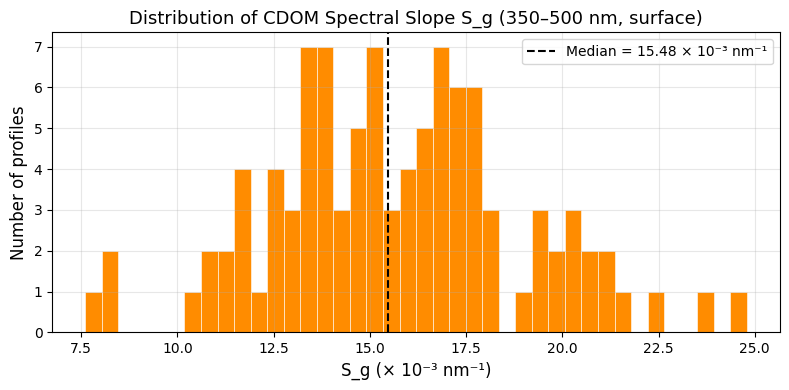

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# Fit Sg per profile (TIME × DEPTH × station_name)
wl_min, wl_max = 350, 500
df_fit = df[(df['wavelength'] >= wl_min) & (df['wavelength'] <= wl_max) &
            (df['DEPTH'] <= 2)].dropna(subset=['ag']).copy()
df_fit = df_fit[df_fit['ag'] > 0]  # log requires positive values

sg_values = []
for (time, sta, depth), grp in df_fit.groupby(['TIME', 'station_name', 'DEPTH']):
    grp = grp.sort_values('wavelength')
    if len(grp) < 20:
        continue
    try:
        slope, intercept, r, p, se = linregress(grp['wavelength'], np.log(grp['ag']))
        sg = -slope
        if 0.005 < sg < 0.04:   # physically plausible range
            sg_values.append(sg)
    except Exception:
        pass

sg_values = np.array(sg_values)
print(f"Profiles fitted: {len(sg_values)}")

if len(sg_values) == 0:
    print("No profiles could be fitted — check that 'ag' data is present in the filtered region.")
else:
    print(f"Sg median: {np.median(sg_values)*1000:.2f} × 10⁻³ nm⁻¹")
    print(f"Sg IQR:    {np.percentile(sg_values,25)*1000:.2f} – {np.percentile(sg_values,75)*1000:.2f} × 10⁻³ nm⁻¹")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(sg_values * 1000, bins=40, color='darkorange', edgecolor='white', linewidth=0.4)
    ax.axvline(np.median(sg_values)*1000, color='black', linestyle='--', linewidth=1.5,
               label=f'Median = {np.median(sg_values)*1000:.2f} × 10⁻³ nm⁻¹')
    ax.set_xlabel('S_g (× 10⁻³ nm⁻¹)', fontsize=12)
    ax.set_ylabel('Number of profiles', fontsize=12)
    ax.set_title('Distribution of CDOM Spectral Slope S_g (350–500 nm, surface)', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Depth Profiles of Absorption at 443 nm

How absorption components change with depth reveals the vertical structure of the water column.
- **ag** typically decreases with depth (CDOM photo-bleaches near the surface, dilutes below thermocline)
- **aph** often peaks at the **Deep Chlorophyll Maximum (DCM)** — the subsurface layer
  where phytoplankton concentrate to balance light and nutrients


/tmp/ipykernel_818944/3079365783.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub['depth_bin'] = (sub['DEPTH'] // 5) * 5 + 2.5
/tmp/ipykernel_818944/3079365783.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub['depth_bin'] = (sub['DEPTH'] // 5) * 5 + 2.5


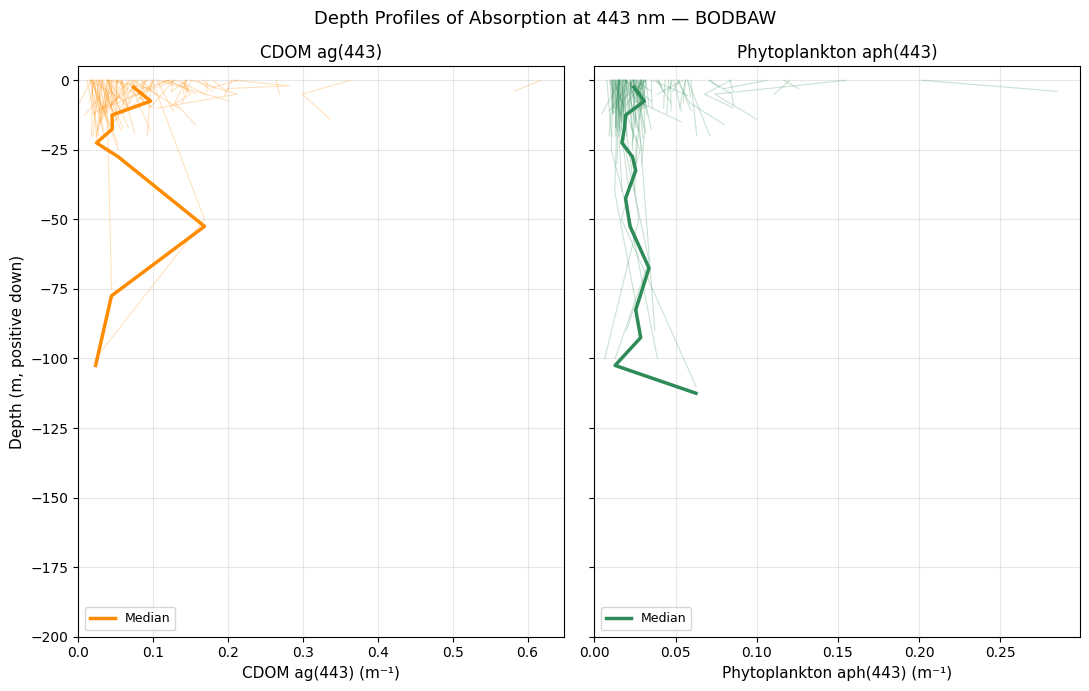

In [16]:
import matplotlib.pyplot as plt
import numpy as np

all_wl = df['wavelength'].dropna().unique()
nearest_443 = all_wl[np.argmin(np.abs(all_wl - 443))]

df_dp = df[(df['wavelength'].round(1) == round(nearest_443, 1))].copy()
df_dp = df_dp[df_dp['DEPTH'].between(0, 200)]

fig, axes = plt.subplots(1, 2, figsize=(11, 7), sharey=True)

for ax, (var, label, color) in zip(axes, [
        ('ag',  'CDOM ag(443)',           'darkorange'),
        ('aph', 'Phytoplankton aph(443)', 'seagreen'),
    ]):
    sub = df_dp.dropna(subset=[var])
    for _, grp in sub.groupby(['TIME', 'station_name']):
        grp = grp.sort_values('DEPTH')
        if len(grp) < 2:
            continue
        ax.plot(grp[var], -grp['DEPTH'], color=color, alpha=0.25, linewidth=0.8)

    # Bin-median profile (5 m bins)
    sub['depth_bin'] = (sub['DEPTH'] // 5) * 5 + 2.5
    med_prof = sub.groupby('depth_bin')[var].median()
    ax.plot(med_prof.values, -med_prof.index, color=color, linewidth=2.5,
            label='Median', zorder=5)

    ax.set_xlabel(f'{label} (m⁻¹)', fontsize=11)
    ax.set_title(label, fontsize=12)
    ax.set_ylim(-200, 5)
    ax.set_xlim(left=0)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Depth (m, positive down)', fontsize=11)
fig.suptitle('Depth Profiles of Absorption at 443 nm — BODBAW', fontsize=13)
plt.tight_layout()
plt.show()
